**Quantum Darwinism: QMI + Holevo + Discord**

*Classic scenario: sys + envir_frag*


In [9]:
# Quantum Darwinism: System + Environment fragments (Theta = π/2)
from qiskit import QuantumCircuit
from qiskit import quantum_info as qi
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit.circuit.library import U3Gate
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
from qiskit import qpy

class QCircuit:    
    def __init__(self, theta, phi, n):  
        self.theta = theta   
        self.phi = phi       
        self.n = n           

    def Circuit(self): 
        qc = QuantumCircuit(self.n)
        qb_sys   = 0
        qb_envir = list(range(1, self.n))
        # System prepare |+> using Hadamard gate 
        qc.h(qb_sys)
        # System entangled with environment
        for i in qb_envir:
            cu_gate = U3Gate(self.theta, self.phi, 0).control(1)
            qc.append(cu_gate, [qb_sys, i])
        return qc 
    
    def DensityMatrix(self): 
        return qi.DensityMatrix.from_instruction(self.Circuit())  
    
    def get_reduced_dm(self, keep_qubits):
        trace_out_qubits = [i for i in range(self.n) if i not in keep_qubits]
        rho = self.DensityMatrix()
        return partial_trace(rho, trace_out_qubits).data

class QuantumInformation(): 

    # Von Neumann entropy
    def VNE(self, state):
        eigenvalues, _ = np.linalg.eigh(state)
        eigenvalues = eigenvalues[eigenvalues > 1e-12]
        return -np.sum(eigenvalues * np.log2(eigenvalues))
    
    # Quantum mutual information I(S:E) = H(S) + H(E) - H(SE)
    def quantum_mutual_I(self, S_State, E_State, SE_State):
        VNE_S  = self.VNE(S_State)
        VNE_E  = self.VNE(E_State)
        VNE_SE = self.VNE(SE_State)
        return VNE_S + VNE_E - VNE_SE
   
    # Holevo Bound χ(S:F) = S(E) - Σ p_i S(E|i) 
    def HolevoBound(self, rho_SEf, rho_S):
            
            rho_Ef = partial_trace(DensityMatrix(rho_SEf), [0]).data
            S_Ef = self.VNE(rho_Ef)
            
            sum_cond_entropy = 0
            d_Ef = rho_SEf.shape[0] // 2  # Chỉ cần dòng này là đủ, vừa sạch code vừa chạy nhanh
            
            # pointer basis of system S
            proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
            proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
            computational_projections = [proj_0, proj_1]
            
            for proj_S in computational_projections:
                proj_SEf = np.kron(np.eye(d_Ef, dtype=complex), proj_S)
                # probability of outcome i of POVM \Pi_S on System
                p_i = np.real(np.trace(proj_SEf @ rho_SEf))
                
                if p_i > 1e-12:
                    rho_SEf_i = (proj_SEf @ rho_SEf @ proj_SEf) / p_i
                    rho_Ef_i = partial_trace(DensityMatrix(rho_SEf_i), [0]).data
                    sum_cond_entropy += p_i * self.VNE(rho_Ef_i)
                    
            return S_Ef - sum_cond_entropy
    
    # Quantum Discord D(S:F) = I(S:F) - χ(S:F) 
    def quantum_discord(self, rho_SE, rho_S):
        rho_E = partial_trace(DensityMatrix(rho_SE), [0]).data
        I_AB = self.quantum_mutual_I(rho_S, rho_E, rho_SE)
        
        cond_entropy = 0
        d_E = rho_SE.shape[0] // 2  # Đồng bộ hệ S kích thước 2
        
        # Pointer basis giống y hệt HolevoBound
        proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
        proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
        pointer_projections = [proj_0, proj_1]
        
        for proj_S in pointer_projections:
            # Sửa lại thứ tự kron để khớp với quy ước Qiskit Little-Endian
            proj_SE = np.kron(np.eye(d_E, dtype=complex), proj_S) 
            
            p_i = np.real(np.trace(proj_SE @ rho_SE))
            if p_i > 1e-12:
                rho_SE_i = (proj_SE @ rho_SE @ proj_SE) / p_i
                rho_B_i = partial_trace(DensityMatrix(rho_SE_i), [0]).data
                cond_entropy += p_i * self.VNE(rho_B_i)
        
        S_B = self.VNE(rho_E)
        classical_corr = S_B - cond_entropy
        return I_AB - classical_corr
    
# ========== MAIN ==========
numQubits = 11 # q0 system, q1..q10 environment
theta, phi = np.pi/2, 0
qc = QCircuit(theta, phi, numQubits)
QI_calc = QuantumInformation()

rho_S = qc.get_reduced_dm([0])
env_qubits = list(range(1, numQubits))

results_S_Envir, results_Discord, results_Holevo = [], [], []

for k in range(1, len(env_qubits)+1):

    Ef = env_qubits[:k]
    rho_Ef   = qc.get_reduced_dm(Ef)
    rho_SEf  = qc.get_reduced_dm([0]+Ef)

    # QMI
    QMI_S_Ef = QI_calc.quantum_mutual_I(rho_S, rho_Ef, rho_SEf)
    results_S_Envir.append(QMI_S_Ef)
    # Holevo
    Holevo_Ef = QI_calc.HolevoBound(rho_SEf, rho_S)
    results_Holevo.append(Holevo_Ef)
    # Quantum Discord
    Discord_S_Ef = QI_calc.quantum_discord(rho_SEf, rho_S)
    results_Discord.append(Discord_S_Ef)

qcircuit_obj = qc.Circuit()

rho_E_full  = qc.get_reduced_dm(env_qubits)

rho_SE_full = qc.get_reduced_dm([0]+env_qubits)

QMI_S_Efull = QI_calc.quantum_mutual_I(rho_S, rho_E_full, rho_SE_full)

Holevo_E_full = QI_calc.HolevoBound(rho_SE_full, rho_S)

Discord_SE_full = QI_calc.quantum_discord(rho_SE_full, rho_S)

# ===================== SAVING ====================

# Working directory
os.chdir("/Users/trandon/Documents/Theoretical Physics/Quantum Darwinism Simulation")

data = {
    "results_S_Envir": results_S_Envir,
    "results_Holevo": results_Holevo,
    "results_Discord": results_Discord,
    "QMI_S_Efull": QMI_S_Efull,
    "Holevo_E_full": Holevo_E_full,
    "Discord_SE_full": Discord_SE_full,
    "qcircuit_obj": qcircuit_obj
}

with open("quantum_darwinism_QMI_Holevo_Discord.pkl", "wb") as f:
    pickle.dump(data, f)

print("="*50)
print(f"Saved quantum_darwinism_QMI_Holevo_Discord.pkl to the working directory: {os.getcwd()}")
print("="*50)


/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_72786/1258207280.py:70: RuntimeWarning: divide by zero encountered in matmul
  p_i = np.real(np.trace(proj_SEf @ rho_SEf))
/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_72786/1258207280.py:70: RuntimeWarning: overflow encountered in matmul
  p_i = np.real(np.trace(proj_SEf @ rho_SEf))
/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_72786/1258207280.py:70: RuntimeWarning: invalid value encountered in matmul
  p_i = np.real(np.trace(proj_SEf @ rho_SEf))
/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_72786/1258207280.py:73: RuntimeWarning: divide by zero encountered in matmul
  rho_SEf_i = (proj_SEf @ rho_SEf @ proj_SEf) / p_i
/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_72786/1258207280.py:73: RuntimeWarning: overflow encountered in matmul
  rho_SEf_i = (proj_SEf @ rho_SEf @ proj_SEf) / p_i
/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_72786/1258207280.py:73: RuntimeW

Saved quantum_darwinism_QMI_Holevo_Discord.pkl to the working directory: /Users/trandon/Documents/Theoretical Physics/Quantum Darwinism Simulation


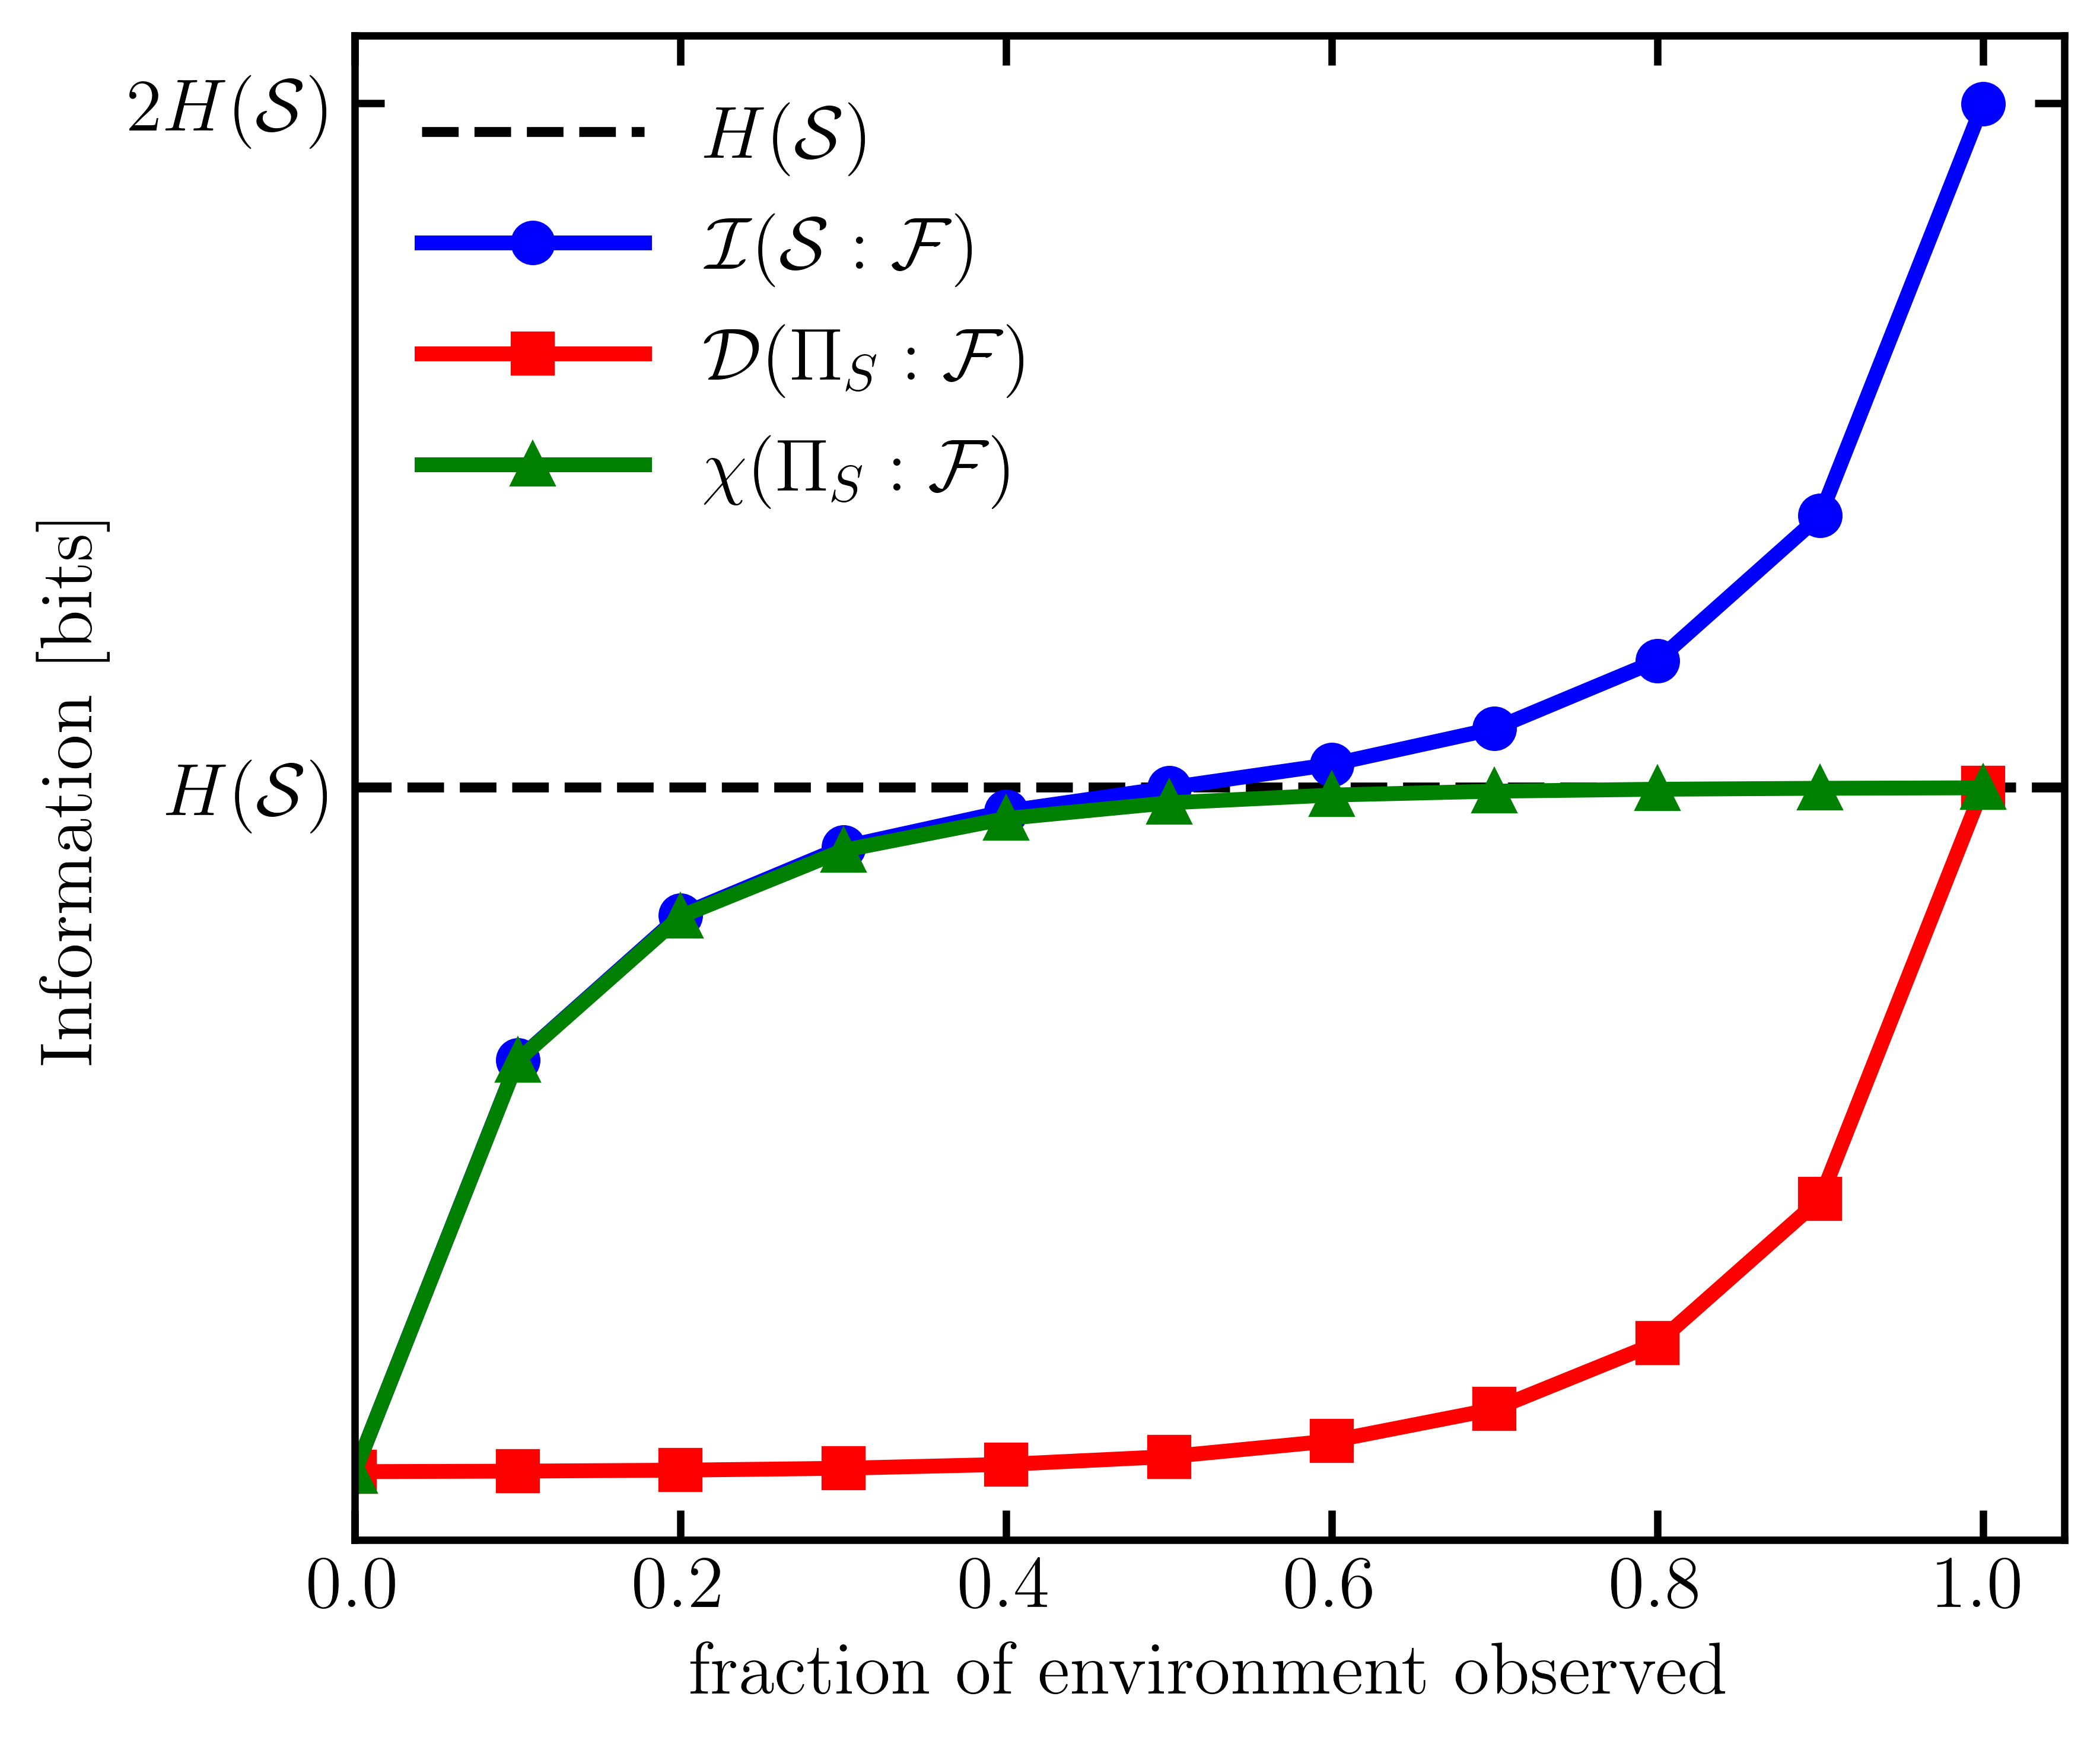

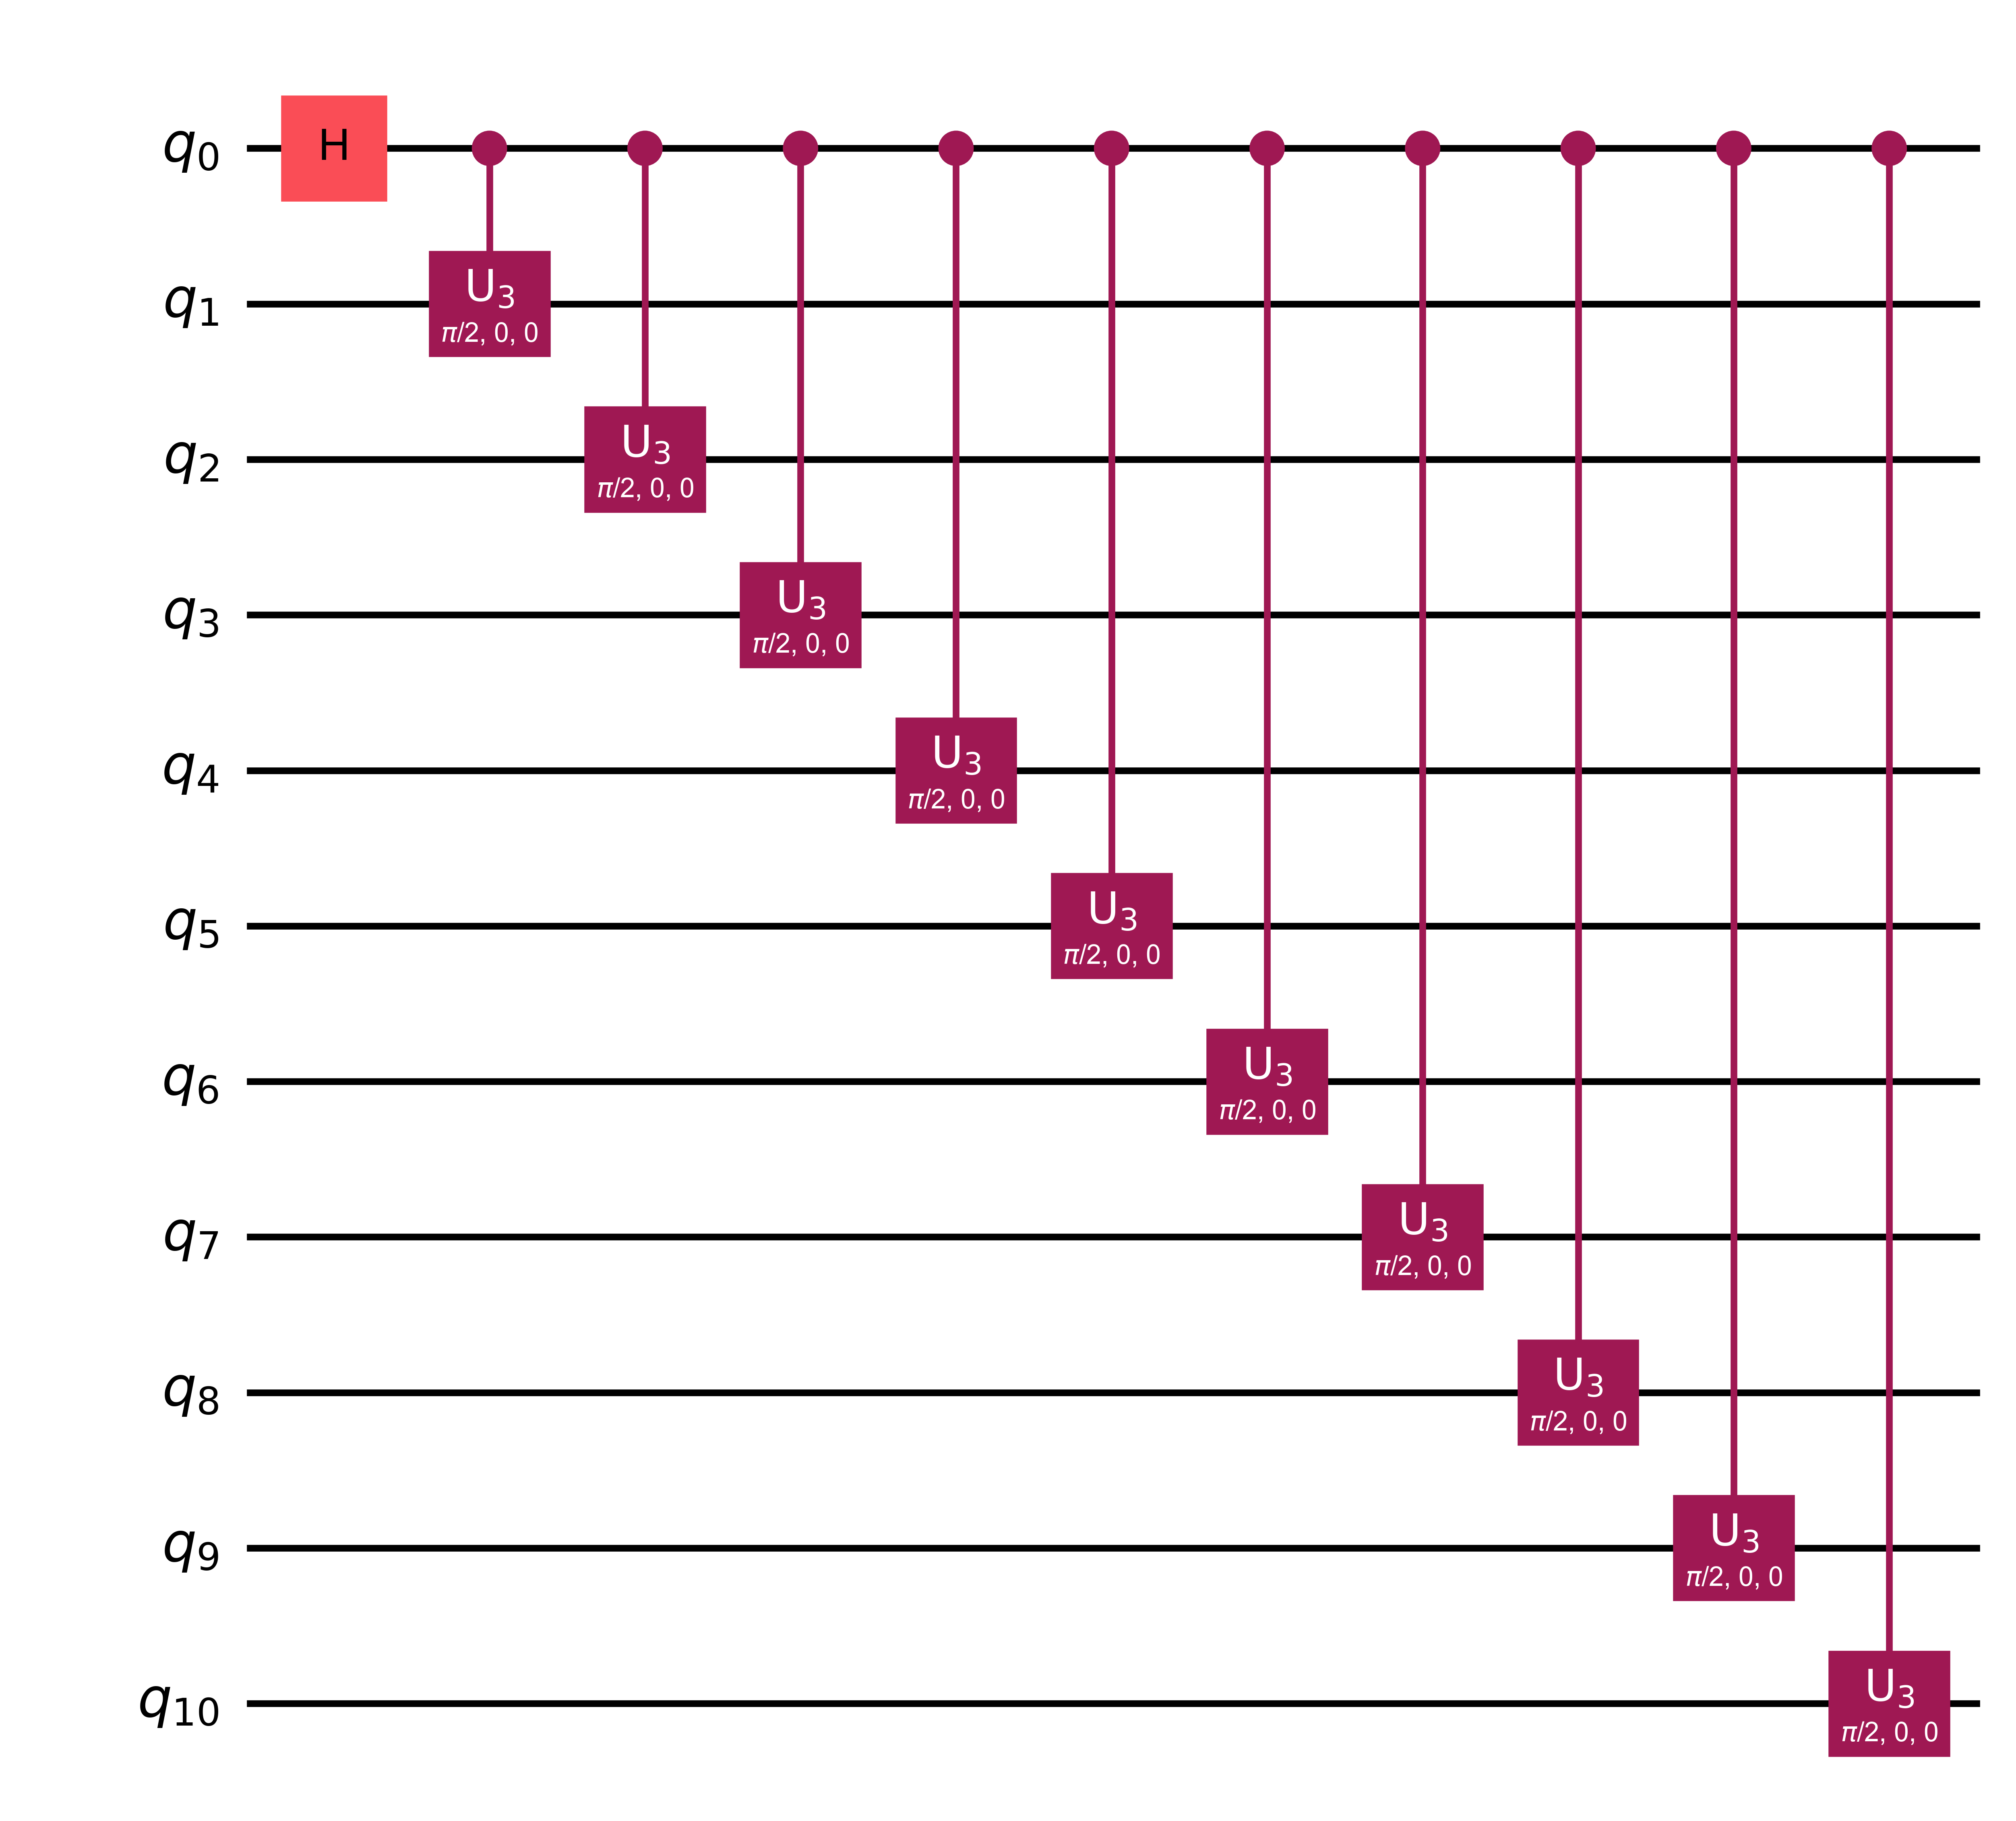

In [10]:
# Plotting classic scenario 

import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import os
import pickle
import os
from IPython.display import display

os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

mpl.rcParams['figure.dpi'] = 600
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Computer Modern Roman']
mpl.rcParams['axes.unicode_minus'] = False
# Working directory
os.chdir("/Users/trandon/Documents/Theoretical Physics/Quantum Darwinism Simulation")

with open("quantum_darwinism_QMI_Holevo_Discord.pkl", "rb") as f:
    data = pickle.load(f)

results_S_Envir = data["results_S_Envir"]
results_Holevo = data["results_Holevo"]
results_Discord = data["results_Discord"]

numQubits = 11
env_qubits = list(range(1, numQubits))

plt.figure(figsize=(6,5))
fs = np.array(range(1, len(env_qubits)+1)) / len(env_qubits)   # từ 0 đến 1
fs_ext = np.concatenate([[0], fs])

results_ext = np.concatenate([[0.0], results_S_Envir])
discord_ext = np.concatenate([[0.0], results_Discord])
holevo_ext = np.concatenate([[0.0], results_Holevo])

plt.axhline(1.0, color='black', linestyle='--', linewidth=2,
            label=r"$H(\mathcal{S})$")

plt.plot(fs_ext, results_ext, 'b-o', linewidth=3, markersize=8,
         label=r"$\mathcal{I}(\mathcal{S}:\mathcal{F})$")

plt.plot(fs_ext, discord_ext, 'r-s', linewidth=3, markersize=8,
         label=r"$\mathcal{D}(\Pi_{S}:\mathcal{F})$")

plt.plot(fs_ext, holevo_ext, 'g-^', linewidth=3, markersize=8,
         label=r"$\chi(\Pi_S:\mathcal{F})$")


ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(width=1.5, length=6, direction="in", top=True, right=True)

yticks = [1.0, 2.0]
labels = [r"$H(\mathcal{S})$", r"$2H(\mathcal{S})$"]
plt.yticks(yticks, labels, fontsize = 15)
plt.xticks(fontsize=15)
plt.xlabel('fraction of environment observed', fontsize=15)
plt.ylabel('Information [bits]', fontsize=15)
plt.title('', fontsize=15, fontweight='bold')
plt.legend(fontsize=15, frameon=False, loc='best', handlelength=3)
plt.grid(False)
plt.xlim(0, 1.05)
plt.tight_layout()
plt.show()

mpl.rcParams['text.usetex'] = False
loaded_circuit = data["qcircuit_obj"]

# Vẽ mạch ra figure
fig = loaded_circuit.draw("mpl")

# Đổi font của tất cả text trong figure sang Arial
for ax in fig.get_axes():
    for text in ax.texts:
        text.set_fontfamily("Arial")

display(fig)


*With observer scenario: sys + envir_frag + obs*

In [27]:
# Quantum Darwinism: System + Observer + Environment (Theta = π/2)
from qiskit import QuantumCircuit
from qiskit import quantum_info as qi
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit.circuit.library import U3Gate
import numpy as np
import matplotlib.pyplot as plt

class QCircuit:    
    def __init__(self, theta, phi, n):  
        self.theta = theta   
        self.phi = phi       
        self.n = n           

    def Circuit(self): 
        qc = QuantumCircuit(self.n)
        qb_sys   = 0
        qb_obser = 1
        qb_envir = list(range(2, self.n))
        
        # System prepare |+>
        qc.h(qb_sys)
        # System entangled with observer
        qc.cx(qb_sys, qb_obser)
        # System entangled with environment
        for i in qb_envir:
            cu_gate = U3Gate(self.theta, self.phi, 0).control(1)
            qc.append(cu_gate, [qb_obser, i])
        return qc 
    
    def DensityMatrix(self): 
        return qi.DensityMatrix.from_instruction(self.Circuit())  
    
    def get_reduced_dm(self, keep_qubits):
        trace_out_qubits = [i for i in range(self.n) if i not in keep_qubits]
        rho = self.DensityMatrix()
        return partial_trace(rho, trace_out_qubits).data

class QuantumInformation(): 

    # Von Neumann entropy
    def VNE(self, state):
        eigenvalues, _ = np.linalg.eigh(state)
        eigenvalues = eigenvalues[eigenvalues > 1e-12]
        return -np.sum(eigenvalues * np.log2(eigenvalues))
    # Quantum mutual information I(S:E) = H(S) + H(E) - H(SE)
    def quantum_mutual_I(self, S_State, E_State, SE_State):
        VNE_S  = self.VNE(S_State)
        VNE_E  = self.VNE(E_State)
        VNE_SE = self.VNE(SE_State)
        return VNE_S + VNE_E - VNE_SE
    def HolevoBound(self, rho_SEf, rho_S):
            
            rho_Ef = partial_trace(DensityMatrix(rho_SEf), [0]).data
            S_Ef = self.VNE(rho_Ef)
            
            sum_cond_entropy = 0
            d_Ef = rho_SEf.shape[0] // 2  # Chỉ cần dòng này là đủ, vừa sạch code vừa chạy nhanh
            
            # pointer basis of system S
            proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
            proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
            computational_projections = [proj_0, proj_1]
            
            for proj_S in computational_projections:
                proj_SEf = np.kron(np.eye(d_Ef, dtype=complex), proj_S)
                # probability of outcome i of POVM \Pi_S on System
                p_i = np.real(np.trace(proj_SEf @ rho_SEf))
                
                if p_i > 1e-12:
                    rho_SEf_i = (proj_SEf @ rho_SEf @ proj_SEf) / p_i
                    rho_Ef_i = partial_trace(DensityMatrix(rho_SEf_i), [0]).data
                    sum_cond_entropy += p_i * self.VNE(rho_Ef_i)
                    
            return S_Ef - sum_cond_entropy
    # Quantum Discord D(S:F) = I(S:F) - χ(S:F) sử dụng Pointer Basis đồng bộ
    def quantum_discord(self, rho_SE, rho_S):
        rho_E = partial_trace(DensityMatrix(rho_SE), [0]).data
        I_AB = self.quantum_mutual_I(rho_S, rho_E, rho_SE)
        
        cond_entropy = 0
        d_E = rho_SE.shape[0] // 2  # Đồng bộ hệ S kích thước 2
        
        # Pointer basis giống y hệt HolevoBound
        proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
        proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
        pointer_projections = [proj_0, proj_1]
        
        for proj_S in pointer_projections:
            # Sửa lại thứ tự kron để khớp với quy ước Qiskit Little-Endian
            proj_SE = np.kron(np.eye(d_E, dtype=complex), proj_S)
            
            p_i = np.real(np.trace(proj_SE @ rho_SE))
            if p_i > 1e-12:
                rho_SE_i = (proj_SE @ rho_SE @ proj_SE) / p_i
                rho_B_i = partial_trace(DensityMatrix(rho_SE_i), [0]).data
                cond_entropy += p_i * self.VNE(rho_B_i)
        
        S_B = self.VNE(rho_E)
        classical_corr = S_B - cond_entropy
        return I_AB - classical_corr

# ========== MAIN ==========
numQubits = 12  # q0 system, q1 observer, q2..q11 environment
theta, phi = np.pi/2, 0
qc = QCircuit(theta, phi, numQubits)
QI_calc = QuantumInformation()
rho_S = qc.get_reduced_dm([0])
env_qubits = list(range(2, numQubits))

# Between system S and environment E
results_S_Envir, results_Discord, results_Holevo = [], [], []

for k in range(1, len(env_qubits)+1):
    Ef = env_qubits[:k]
    rho_Ef   = qc.get_reduced_dm(Ef)
    rho_SEf  = qc.get_reduced_dm([0]+Ef)
    # QMI ( S: E_f )
    QMI_S_Ef = QI_calc.quantum_mutual_I(rho_S, rho_Ef, rho_SEf)
    results_S_Envir.append(QMI_S_Ef)
    # Holevo ( S: E_f )
    Holevo_Ef = QI_calc.HolevoBound(rho_SEf, rho_S)
    results_Holevo.append(Holevo_Ef)
    # Discord ( S: E_f )
    Discord_S_Ef = QI_calc.quantum_discord(rho_SEf, rho_S)
    results_Discord.append(Discord_S_Ef)
 

# Betwween obsever F and environment E
results_F_Envir, results_Discord_F, results_Holevo_F = [], [], []

for k in range(1, len(env_qubits)+1):
    Ef = env_qubits[:k]
    rho_Ef   = qc.get_reduced_dm(Ef)
    rho_FEf  = qc.get_reduced_dm([1]+Ef)
    # QMI ( F: E_f )
    QMI_F_Ef = QI_calc.quantum_mutual_I(qc.get_reduced_dm([1]), rho_Ef, rho_FEf)
    results_F_Envir.append(QMI_F_Ef)
    # Holevo ( F: E_f )
    Holevo_F_Ef = QI_calc.HolevoBound(rho_FEf, qc.get_reduced_dm([1]))
    results_Holevo_F.append(Holevo_F_Ef)
    # Discord ( F: E_f )
    Discord_F_Ef = QI_calc.quantum_discord(rho_FEf, qc.get_reduced_dm([1]))
    results_Discord_F.append(Discord_F_Ef)
# ===================== SAVING ====================

# Working directory
os.chdir("/Users/trandon/Documents/Theoretical Physics/Quantum Darwinism Simulation")

data = {
    "results_S_Envir": results_S_Envir,
    "results_Holevo": results_Holevo,
    "results_Discord": results_Discord,

    "results_F_Envir": results_F_Envir,
    "results_Holevo_F": results_Holevo_F,
    "results_Discord_F": results_Discord_F,
    "qcircuit_obj": qc.Circuit()
}

with open("quantum_darwinism_Wigner_QMI_Holevo_Discord.pkl", "wb") as f:
    pickle.dump(data, f)

print("Saved quantum_darwinism_Wigner_QMI_Holevo_Discord.pkl")


/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_12696/3590240264.py:68: RuntimeWarning: divide by zero encountered in matmul
  p_i = np.real(np.trace(proj_SEf @ rho_SEf))
/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_12696/3590240264.py:68: RuntimeWarning: overflow encountered in matmul
  p_i = np.real(np.trace(proj_SEf @ rho_SEf))
/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_12696/3590240264.py:68: RuntimeWarning: invalid value encountered in matmul
  p_i = np.real(np.trace(proj_SEf @ rho_SEf))
/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_12696/3590240264.py:71: RuntimeWarning: divide by zero encountered in matmul
  rho_SEf_i = (proj_SEf @ rho_SEf @ proj_SEf) / p_i
/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_12696/3590240264.py:71: RuntimeWarning: overflow encountered in matmul
  rho_SEf_i = (proj_SEf @ rho_SEf @ proj_SEf) / p_i
/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_12696/3590240264.py:71: RuntimeW

Saved quantum_darwinism_Wigner_QMI_Holevo_Discord.pkl


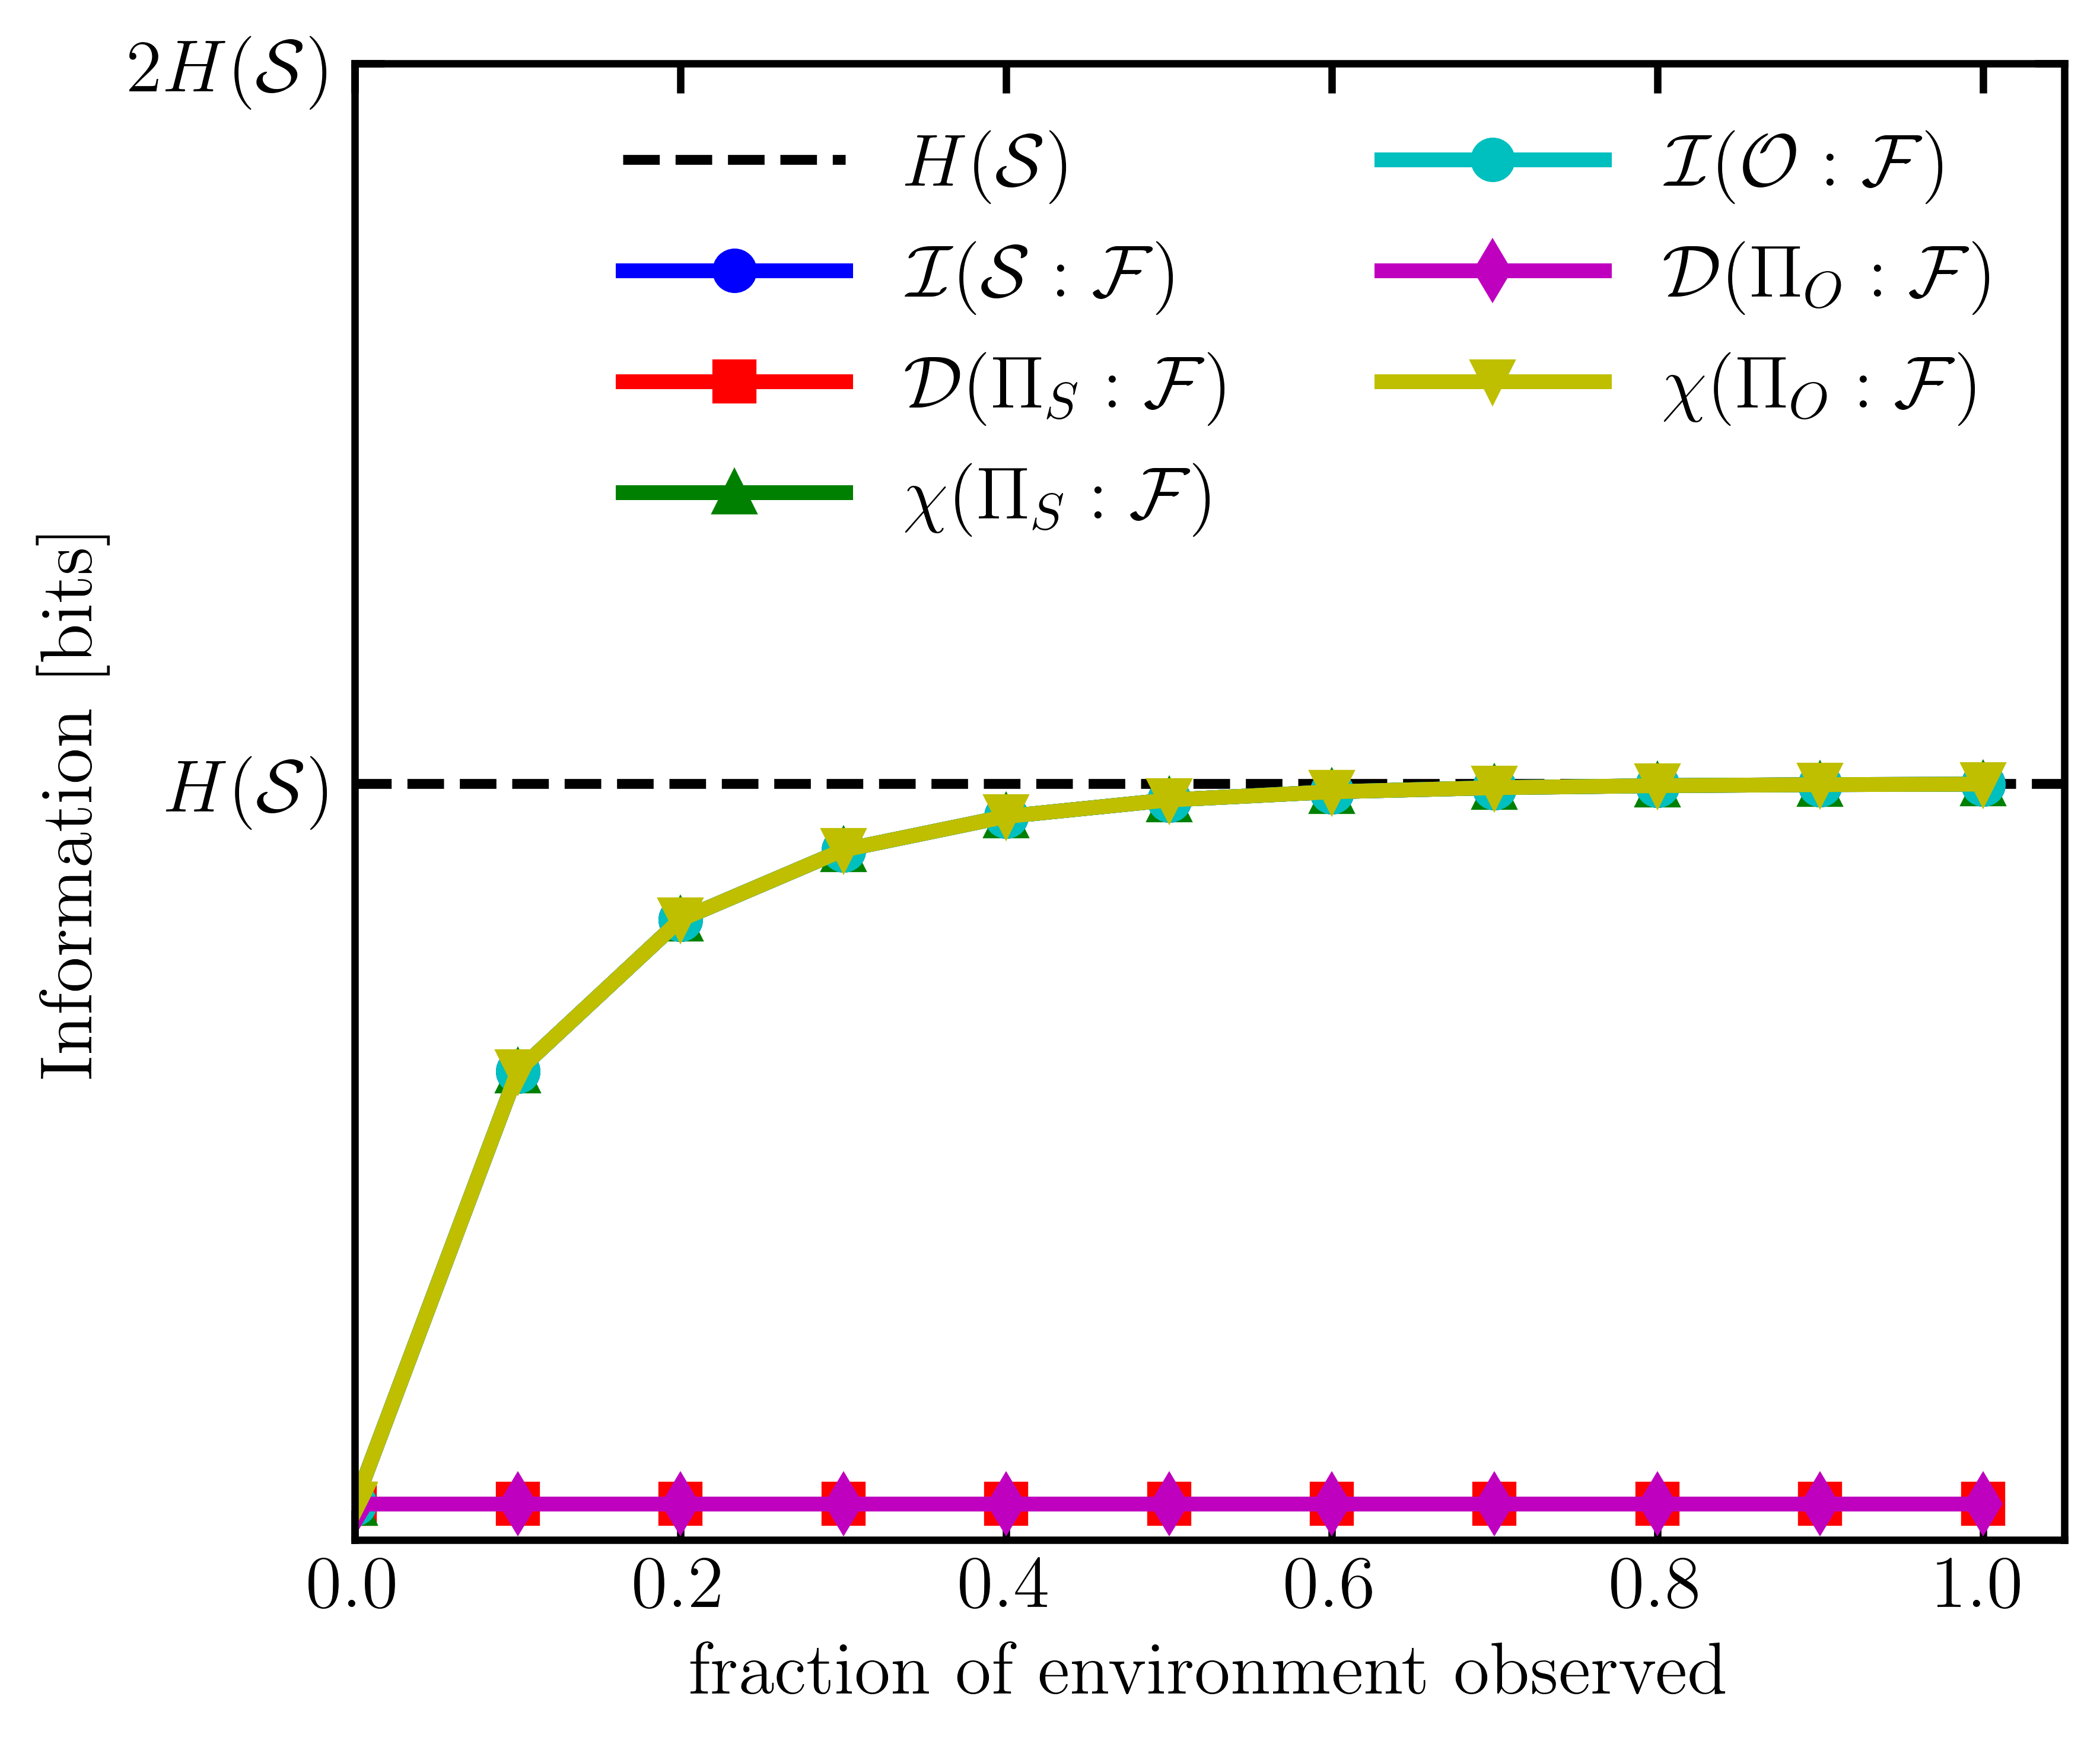

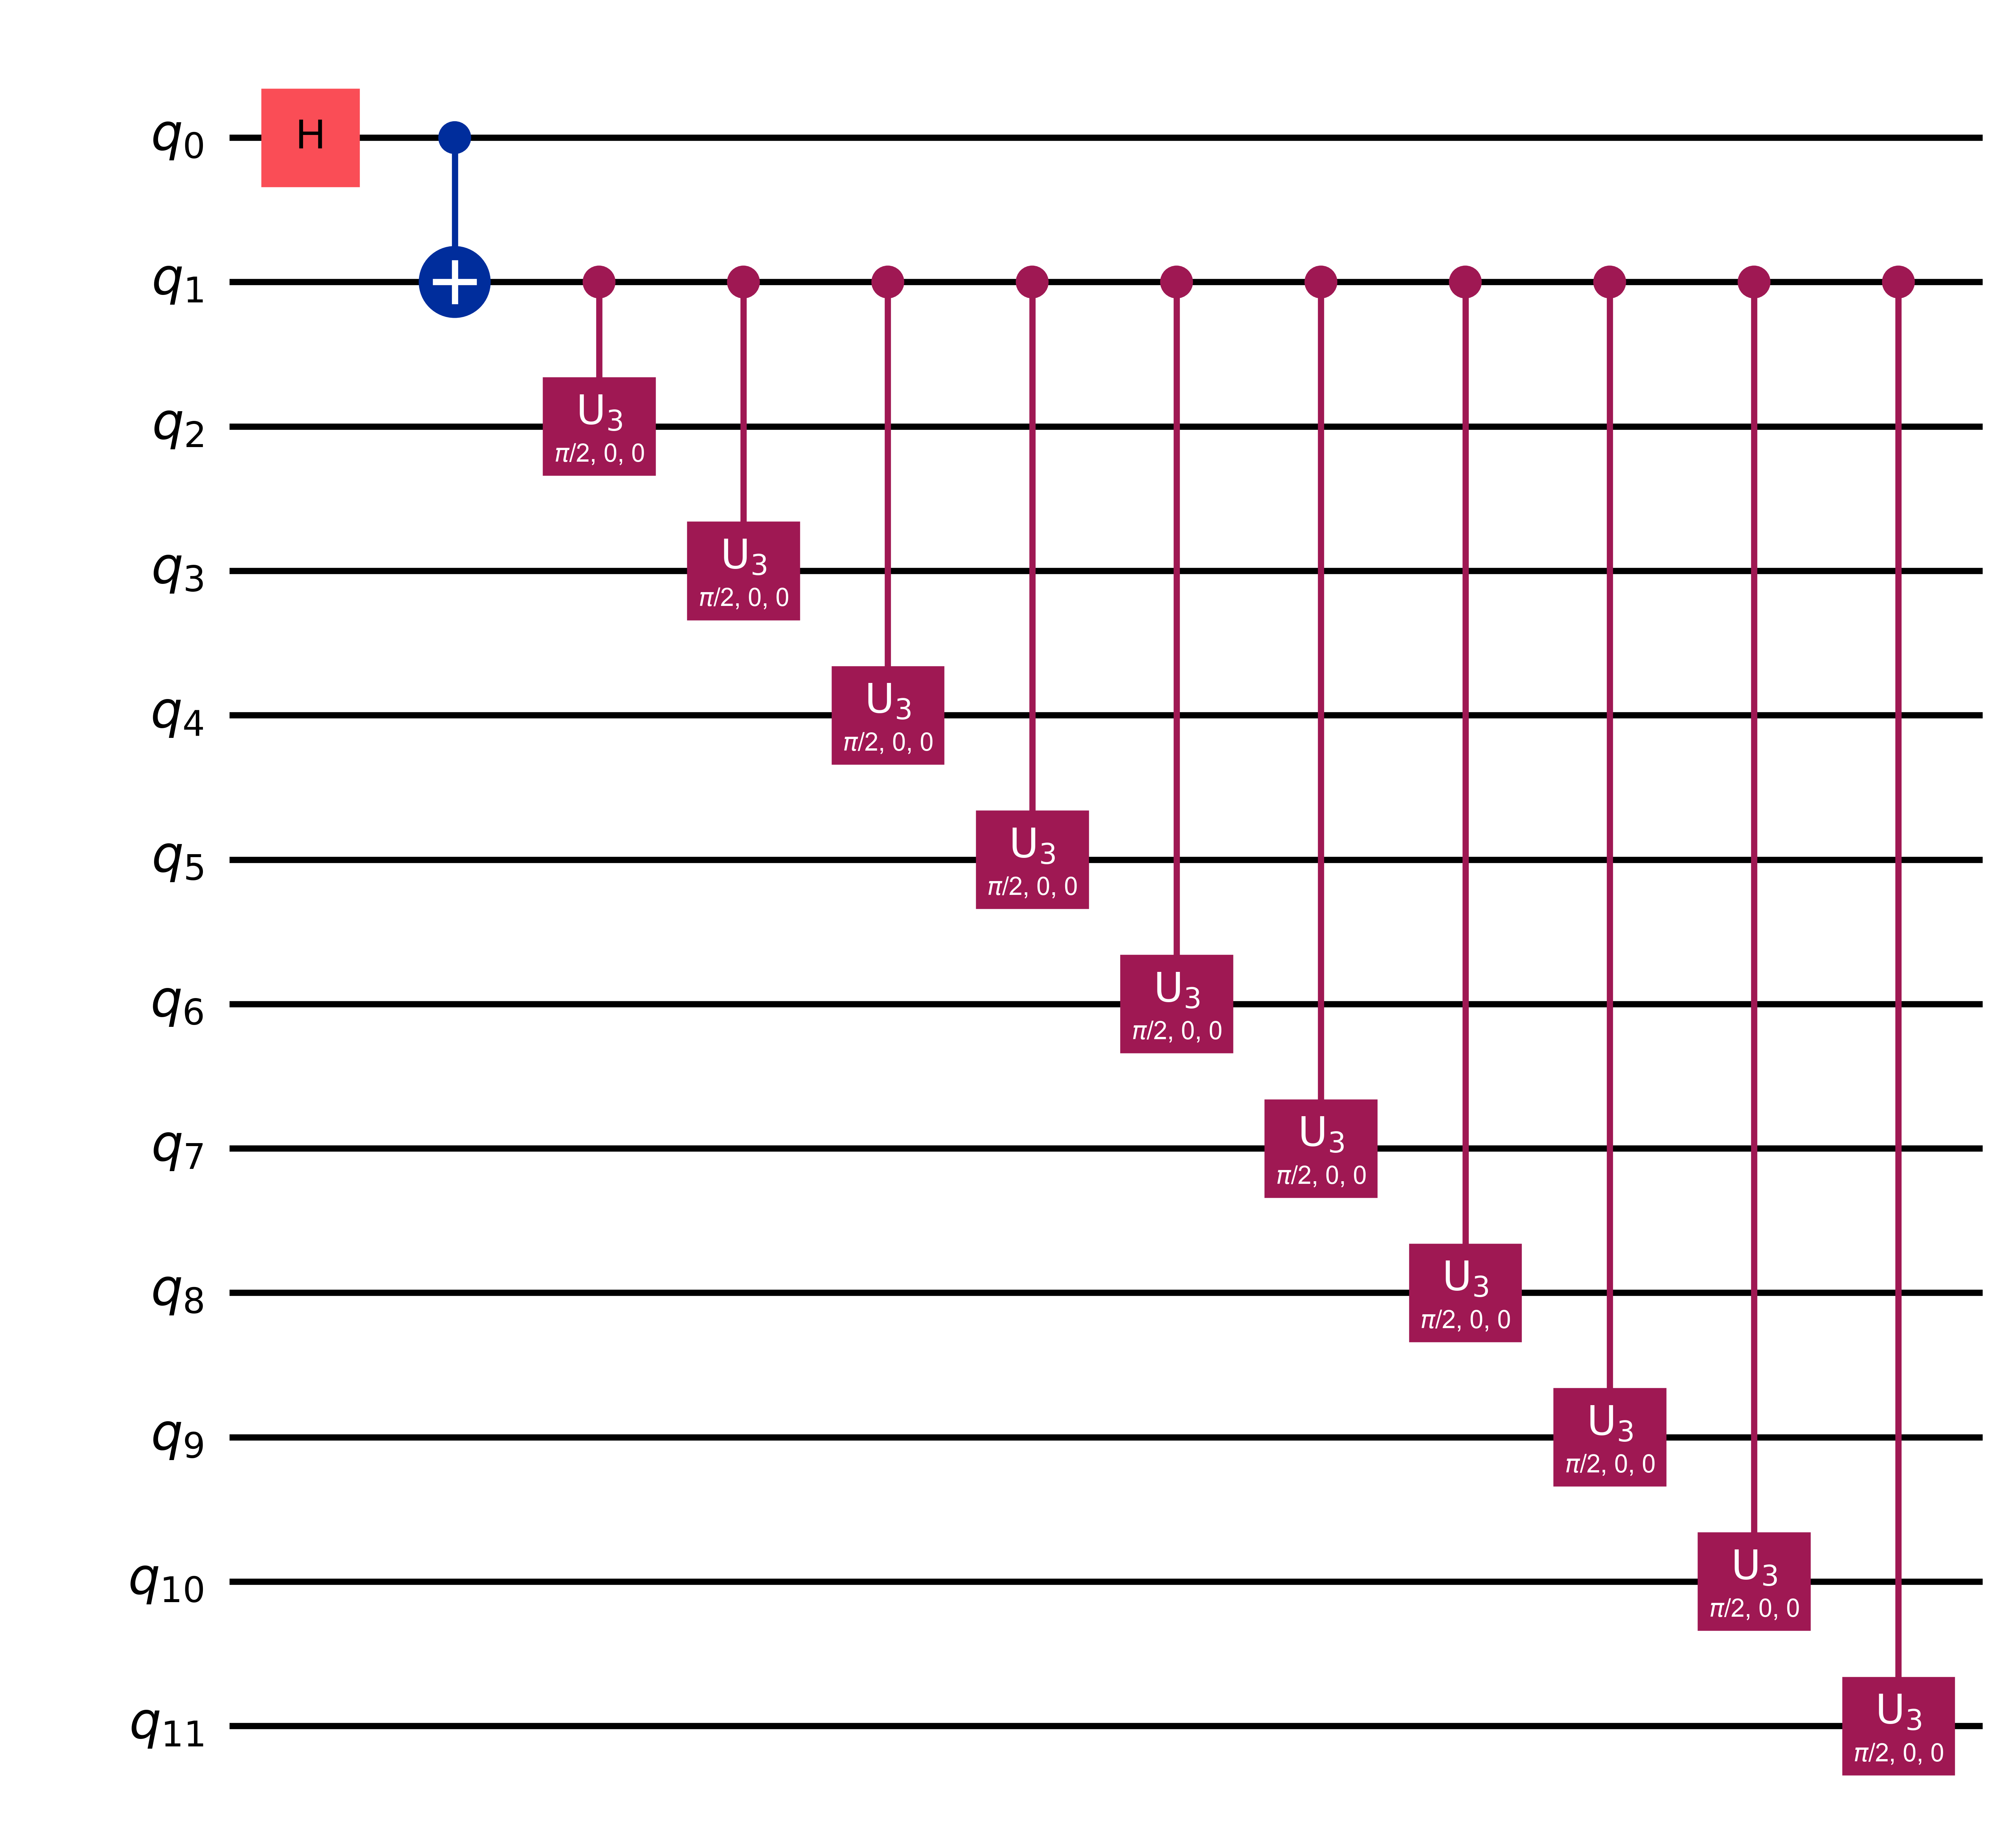

In [13]:
# Plotting Observed scenario 

import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import os
import pickle
import os
from IPython.display import display

os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

mpl.rcParams['figure.dpi'] = 600
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Computer Modern Roman']
mpl.rcParams['axes.unicode_minus'] = False
# Working directory
os.chdir("/Users/trandon/Documents/Theoretical Physics/Quantum Darwinism Simulation")

with open("quantum_darwinism_Wigner_QMI_Holevo_Discord.pkl", "rb") as f:
    data = pickle.load(f)

results_S_Envir = data["results_S_Envir"]
results_Holevo = data["results_Holevo"]
results_Discord = data["results_Discord"]

results_F_Envir = data["results_F_Envir"]
results_Holevo_F = data["results_Holevo_F"]
results_Discord_F = data["results_Discord_F"]

numQubits = 11
env_qubits = list(range(1, numQubits))

plt.figure(figsize=(6,5))
fs = np.array(range(1, len(env_qubits)+1)) / len(env_qubits)   # từ 0 đến 1
fs_ext = np.concatenate([[0], fs])

results_ext = np.concatenate([[0.0], results_S_Envir])
discord_ext = np.concatenate([[0.0], results_Discord])
holevo_ext = np.concatenate([[0.0], results_Holevo])

results_F_ext = np.concatenate([[0.0], results_F_Envir])
discord_F_ext = np.concatenate([[0.0], results_Discord_F])
holevo_F_ext = np.concatenate([[0.0], results_Holevo_F])

plt.axhline(1.0, color='black', linestyle='--', linewidth=2,
            label=r"$H(\mathcal{S})$")

# System–Fragment
plt.plot(fs_ext, results_ext, 'b-o', linewidth=3, markersize=8,
         label=r"$\mathcal{I}(\mathcal{S}:\mathcal{F})$")
plt.plot(fs_ext, discord_ext, 'r-s', linewidth=3, markersize=8,
         label=r"$\mathcal{D}(\Pi_{S}:\mathcal{F})$")
plt.plot(fs_ext, holevo_ext, 'g-^', linewidth=3, markersize=8,
         label=r"$\chi(\Pi_S:\mathcal{F})$")

# Fragment–Environment
plt.plot(fs_ext, results_F_ext, 'c-o', linewidth=3, markersize=8,
         label=r"$\mathcal{I}(\mathcal{O}:\mathcal{F})$")
plt.plot(fs_ext, discord_F_ext, 'm-d', linewidth=3, markersize=8,
         label=r"$\mathcal{D}(\Pi_{O}:\mathcal{F})$")
plt.plot(fs_ext, holevo_F_ext, 'y-v', linewidth=3, markersize=8,
         label=r"$\chi(\Pi_O:\mathcal{F})$")


ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(width=1.5, length=6, direction="in", top=True, right=True)

yticks = [1.0, 2.0]
labels = [r"$H(\mathcal{S})$", r"$2H(\mathcal{S})$"]
plt.yticks(yticks, labels, fontsize = 15)
plt.xticks(fontsize=15)
plt.xlabel('fraction of environment observed', fontsize=15)
plt.ylabel('Information [bits]', fontsize=15)
plt.title('', fontsize=15, fontweight='bold')
plt.legend(fontsize=15, frameon=False, loc='best', handlelength=3, ncol=2)
plt.grid(False)
plt.xlim(0, 1.05)
plt.tight_layout()
plt.show()

mpl.rcParams['text.usetex'] = False
loaded_circuit = data["qcircuit_obj"]

# Vẽ mạch ra figure
fig = loaded_circuit.draw("mpl")

# Đổi font của tất cả text trong figure sang Arial
for ax in fig.get_axes():
    for text in ax.texts:
        text.set_fontfamily("Arial")

display(fig)


In [15]:
# Quantum Darwinism: System + Observer + Environment (Theta = π/2)
from qiskit import QuantumCircuit
from qiskit import quantum_info as qi
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit.circuit.library import U3Gate
import numpy as np
import matplotlib.pyplot as plt

class QCircuit:    
    def __init__(self, theta, phi, n):  
        self.theta = theta   
        self.phi = phi       
        self.n = n           

    def Circuit(self): 
        qc = QuantumCircuit(self.n)
        qb_sys   = 0
        qb_obser = 1
        qb_envir = list(range(2, self.n))
        
        # System prepare |+>
        qc.h(qb_sys)
        # System entangled with observer
        qc.cz(qb_sys, qb_obser)
        # System entangled with environment
        for i in qb_envir:
            cu_gate = U3Gate(self.theta, self.phi, 0).control(1)
            qc.append(cu_gate, [qb_obser, i])
        return qc 
    
    def DensityMatrix(self): 
        return qi.DensityMatrix.from_instruction(self.Circuit())  
    
    def get_reduced_dm(self, keep_qubits):
        trace_out_qubits = [i for i in range(self.n) if i not in keep_qubits]
        rho = self.DensityMatrix()
        return partial_trace(rho, trace_out_qubits).data

class QuantumInformation(): 

    # Von Neumann entropy
    def VNE(self, state):
        eigenvalues, _ = np.linalg.eigh(state)
        eigenvalues = eigenvalues[eigenvalues > 1e-12]
        return -np.sum(eigenvalues * np.log2(eigenvalues))
    # Quantum mutual information I(S:E) = H(S) + H(E) - H(SE)
    def quantum_mutual_I(self, S_State, E_State, SE_State):
        VNE_S  = self.VNE(S_State)
        VNE_E  = self.VNE(E_State)
        VNE_SE = self.VNE(SE_State)
        return VNE_S + VNE_E - VNE_SE
    def HolevoBound(self, rho_SEf, rho_S):
            
            rho_Ef = partial_trace(DensityMatrix(rho_SEf), [0]).data
            S_Ef = self.VNE(rho_Ef)
            
            sum_cond_entropy = 0
            d_Ef = rho_SEf.shape[0] // 2  # Chỉ cần dòng này là đủ, vừa sạch code vừa chạy nhanh
            
            # pointer basis of system S
            proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
            proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
            computational_projections = [proj_0, proj_1]
            
            for proj_S in computational_projections:
                proj_SEf = np.kron(np.eye(d_Ef, dtype=complex), proj_S)
                # probability of outcome i of POVM \Pi_S on System
                p_i = np.real(np.trace(proj_SEf @ rho_SEf))
                
                if p_i > 1e-12:
                    rho_SEf_i = (proj_SEf @ rho_SEf @ proj_SEf) / p_i
                    rho_Ef_i = partial_trace(DensityMatrix(rho_SEf_i), [0]).data
                    sum_cond_entropy += p_i * self.VNE(rho_Ef_i)
                    
            return S_Ef - sum_cond_entropy
    # Quantum Discord D(S:F) = I(S:F) - χ(S:F) sử dụng Pointer Basis đồng bộ
    def quantum_discord(self, rho_SE, rho_S):
        rho_E = partial_trace(DensityMatrix(rho_SE), [0]).data
        I_AB = self.quantum_mutual_I(rho_S, rho_E, rho_SE)
        
        cond_entropy = 0
        d_E = rho_SE.shape[0] // 2  # Đồng bộ hệ S kích thước 2
        
        # Pointer basis giống y hệt HolevoBound
        proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
        proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
        pointer_projections = [proj_0, proj_1]
        
        for proj_S in pointer_projections:
            # Sửa lại thứ tự kron để khớp với quy ước Qiskit Little-Endian
            proj_SE = np.kron(np.eye(d_E, dtype=complex), proj_S)
            
            p_i = np.real(np.trace(proj_SE @ rho_SE))
            if p_i > 1e-12:
                rho_SE_i = (proj_SE @ rho_SE @ proj_SE) / p_i
                rho_B_i = partial_trace(DensityMatrix(rho_SE_i), [0]).data
                cond_entropy += p_i * self.VNE(rho_B_i)
        
        S_B = self.VNE(rho_E)
        classical_corr = S_B - cond_entropy
        return I_AB - classical_corr

# ========== MAIN ==========
numQubits = 12  # q0 system, q1 observer, q2..q11 environment
theta, phi = np.pi/2, 0
qc = QCircuit(theta, phi, numQubits)
QI_calc = QuantumInformation()
rho_S = qc.get_reduced_dm([0])
env_qubits = list(range(2, numQubits))

# Between system S and environment E
results_S_Envir, results_Discord, results_Holevo = [], [], []

for k in range(1, len(env_qubits)+1):
    Ef = env_qubits[:k]
    rho_Ef   = qc.get_reduced_dm(Ef)
    rho_SEf  = qc.get_reduced_dm([0]+Ef)
    # QMI ( S: E_f )
    QMI_S_Ef = QI_calc.quantum_mutual_I(rho_S, rho_Ef, rho_SEf)
    results_S_Envir.append(QMI_S_Ef)
    # Holevo ( S: E_f )
    Holevo_Ef = QI_calc.HolevoBound(rho_SEf, rho_S)
    results_Holevo.append(Holevo_Ef)
    # Discord ( S: E_f )
    Discord_S_Ef = QI_calc.quantum_discord(rho_SEf, rho_S)
    results_Discord.append(Discord_S_Ef)
 

# Betwween obsever F and environment E
results_F_Envir, results_Discord_F, results_Holevo_F = [], [], []

for k in range(1, len(env_qubits)+1):
    Ef = env_qubits[:k]
    rho_Ef   = qc.get_reduced_dm(Ef)
    rho_FEf  = qc.get_reduced_dm([1]+Ef)
    # QMI ( F: E_f )
    QMI_F_Ef = QI_calc.quantum_mutual_I(qc.get_reduced_dm([1]), rho_Ef, rho_FEf)
    results_F_Envir.append(QMI_F_Ef)
    # Holevo ( F: E_f )
    Holevo_F_Ef = QI_calc.HolevoBound(rho_FEf, qc.get_reduced_dm([1]))
    results_Holevo_F.append(Holevo_F_Ef)
    # Discord ( F: E_f )
    Discord_F_Ef = QI_calc.quantum_discord(rho_FEf, qc.get_reduced_dm([1]))
    results_Discord_F.append(Discord_F_Ef)
# ===================== SAVING ====================

# Working directory
os.chdir("/Users/trandon/Documents/Theoretical Physics/Quantum Darwinism Simulation")

data = {
    "results_S_Envir": results_S_Envir,
    "results_Holevo": results_Holevo,
    "results_Discord": results_Discord,

    "results_F_Envir": results_F_Envir,
    "results_Holevo_F": results_Holevo_F,
    "results_Discord_F": results_Discord_F,
    "qcircuit_obj": qc.Circuit()
}

with open("quantum_darwinism_Wigner_CZ_QMI_Holevo_Discord.pkl", "wb") as f:
    pickle.dump(data, f)

print("Saved quantum_darwinism_Wigner_CZ_QMI_Holevo_Discord.pkl")


/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_72786/1627128018.py:68: RuntimeWarning: divide by zero encountered in matmul
  p_i = np.real(np.trace(proj_SEf @ rho_SEf))
/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_72786/1627128018.py:68: RuntimeWarning: overflow encountered in matmul
  p_i = np.real(np.trace(proj_SEf @ rho_SEf))
/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_72786/1627128018.py:68: RuntimeWarning: invalid value encountered in matmul
  p_i = np.real(np.trace(proj_SEf @ rho_SEf))
/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_72786/1627128018.py:71: RuntimeWarning: divide by zero encountered in matmul
  rho_SEf_i = (proj_SEf @ rho_SEf @ proj_SEf) / p_i
/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_72786/1627128018.py:71: RuntimeWarning: overflow encountered in matmul
  rho_SEf_i = (proj_SEf @ rho_SEf @ proj_SEf) / p_i
/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_72786/1627128018.py:71: RuntimeW

Saved quantum_darwinism_Wigner_CZ_QMI_Holevo_Discord.pkl


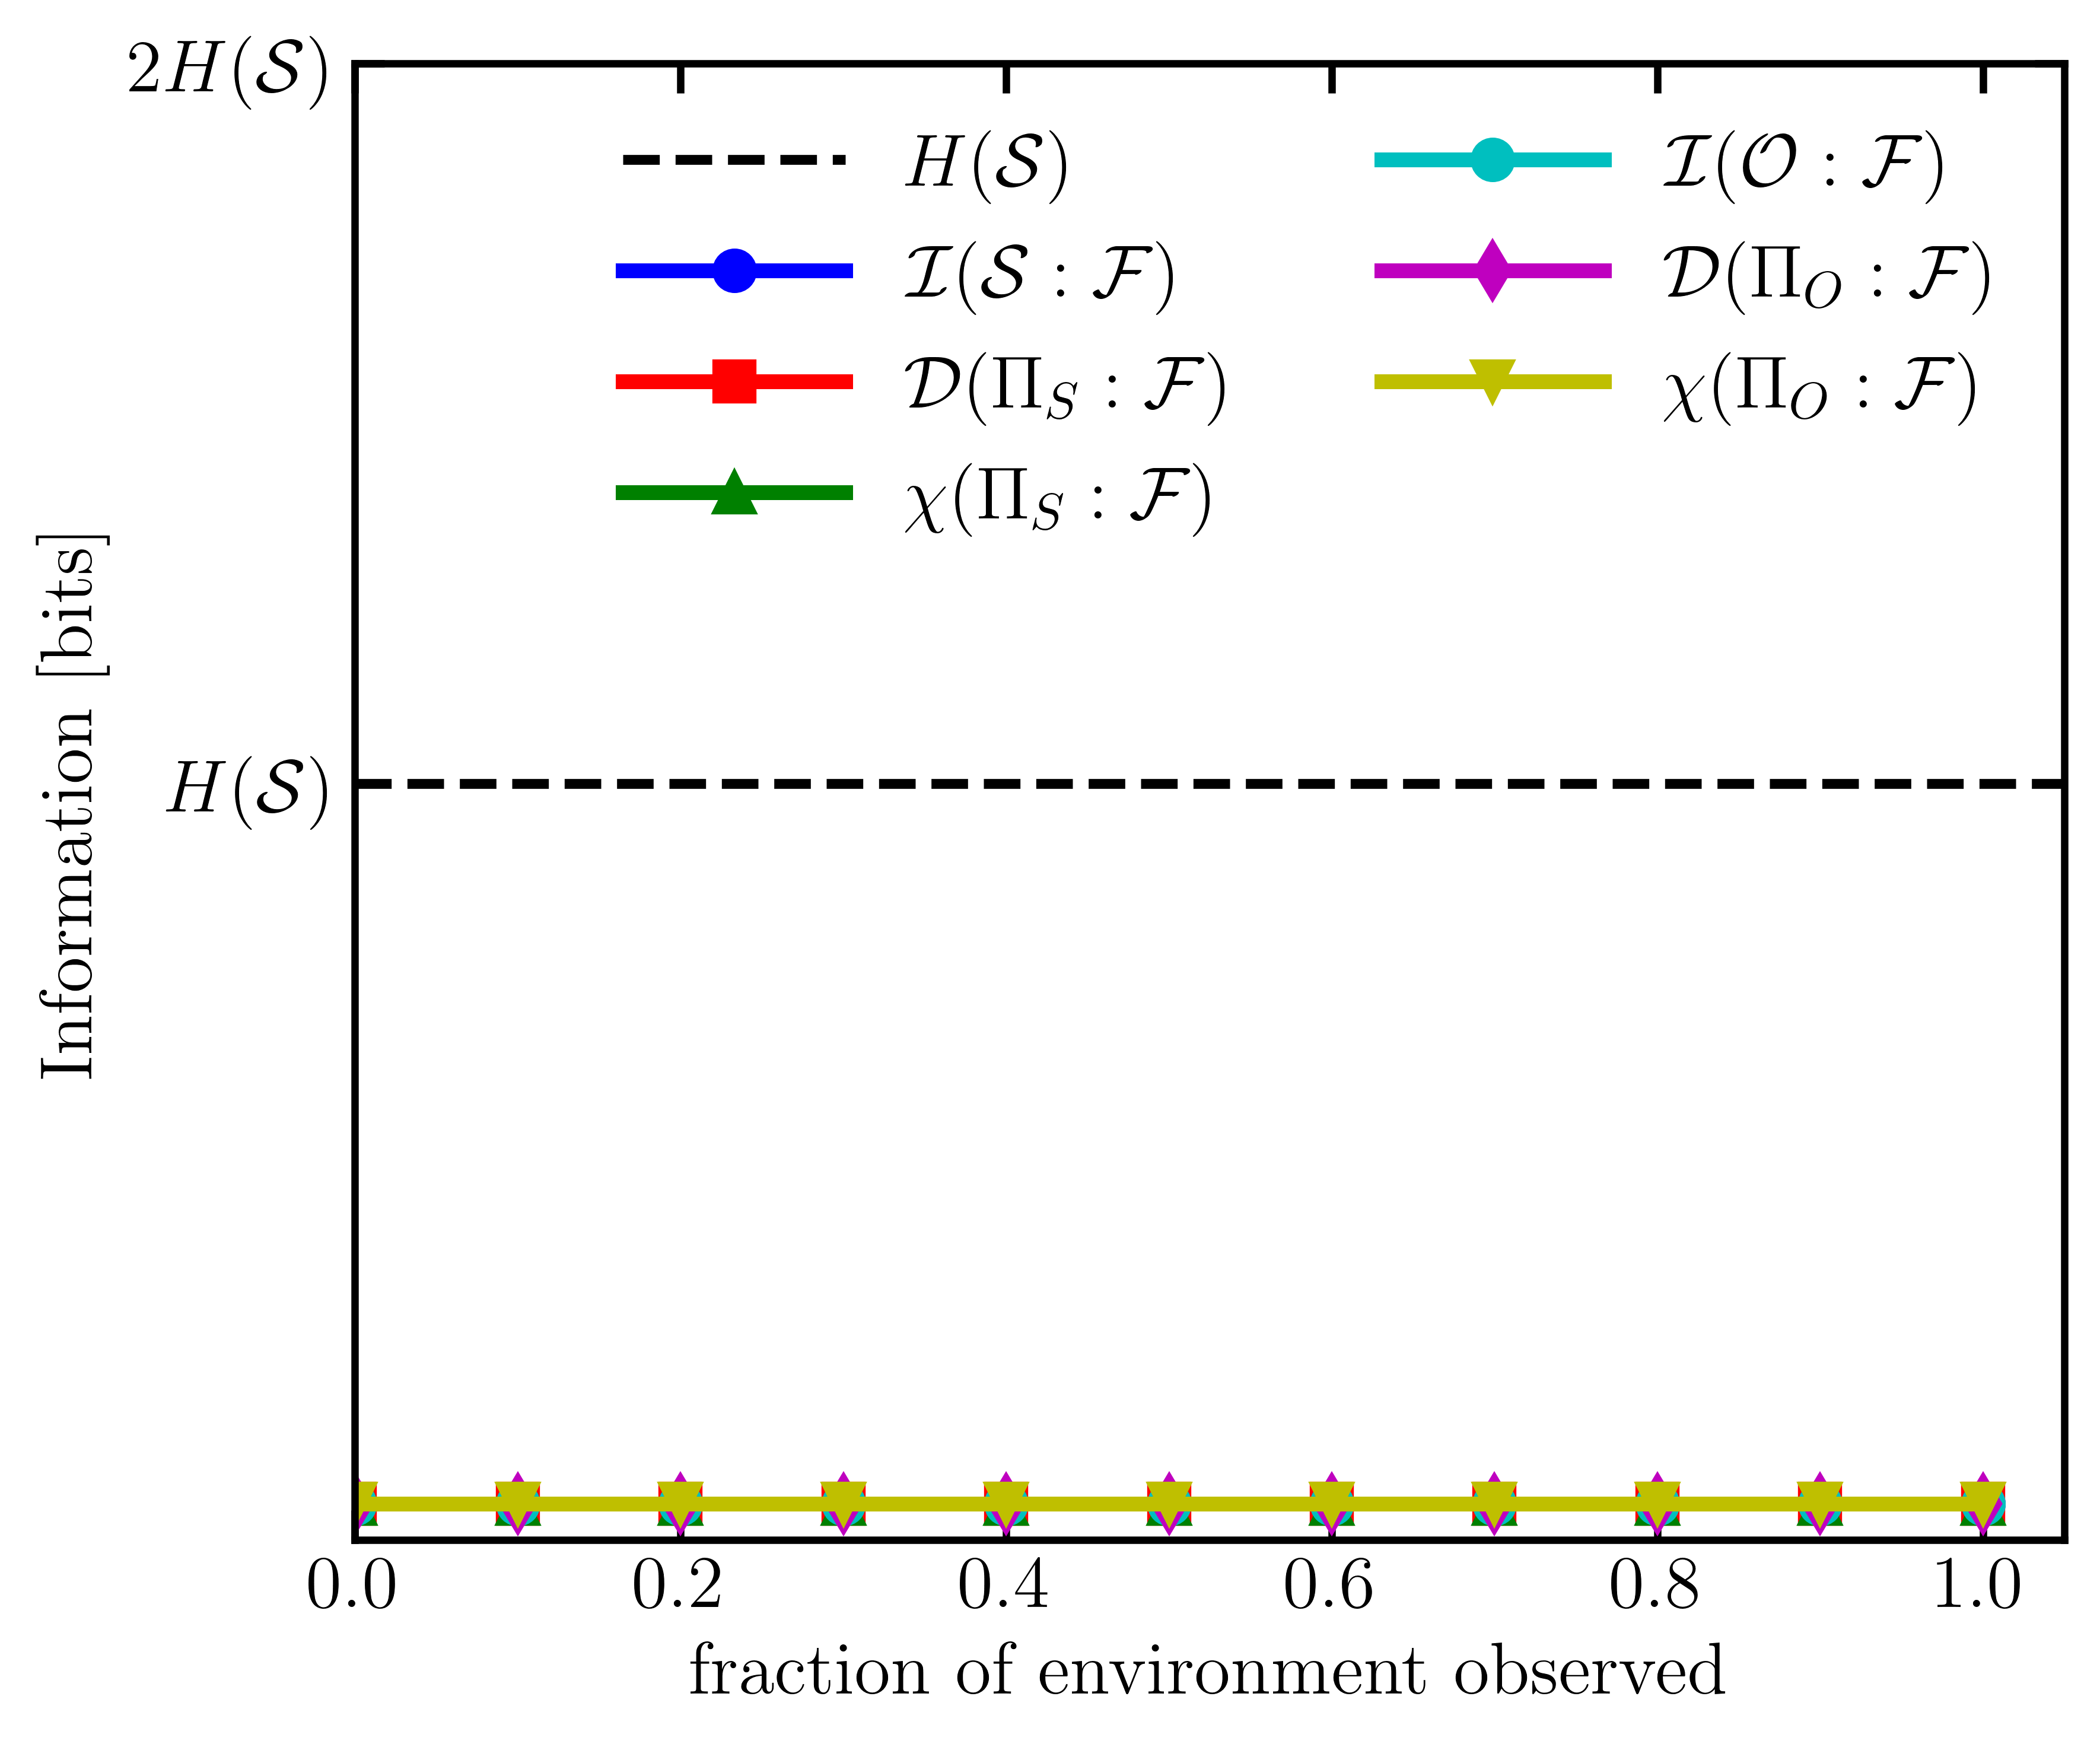

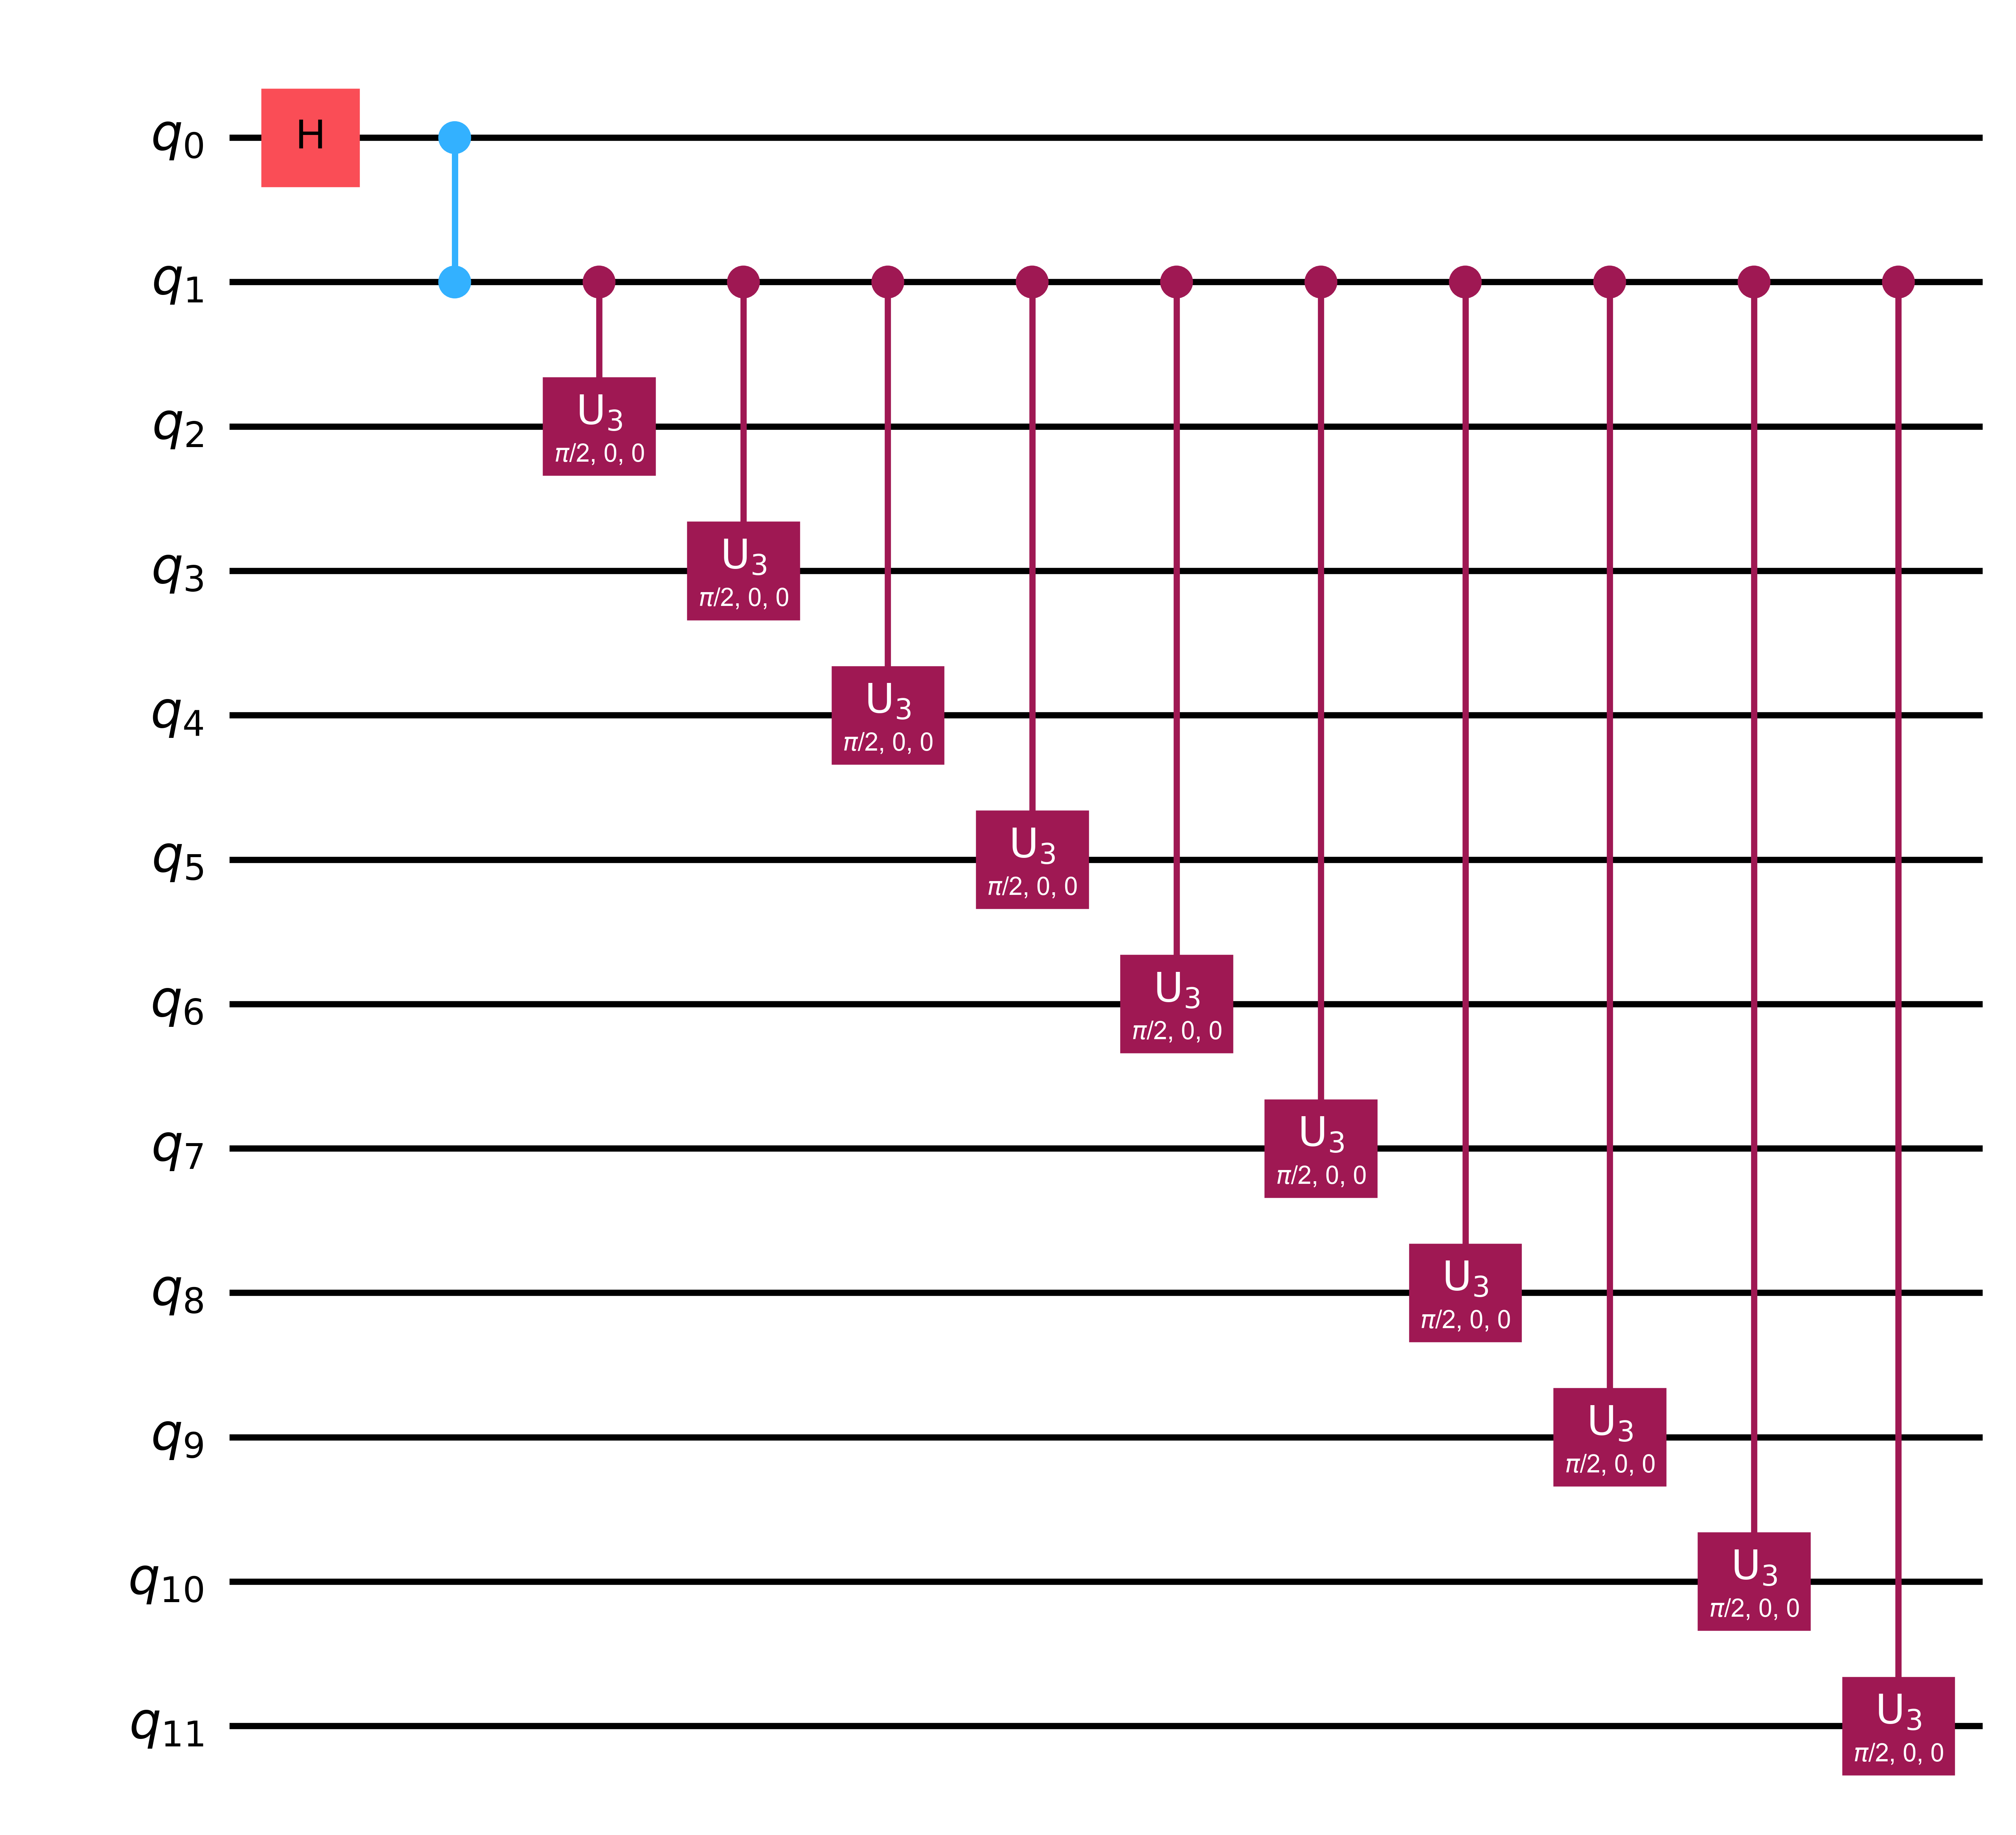

In [16]:
# Plotting Observed scenario 

import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import os
import pickle
import os
from IPython.display import display

os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

mpl.rcParams['figure.dpi'] = 600
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Computer Modern Roman']
mpl.rcParams['axes.unicode_minus'] = False
# Working directory
os.chdir("/Users/trandon/Documents/Theoretical Physics/Quantum Darwinism Simulation")

with open("quantum_darwinism_Wigner_CZ_QMI_Holevo_Discord.pkl", "rb") as f:
    data = pickle.load(f)

results_S_Envir = data["results_S_Envir"]
results_Holevo = data["results_Holevo"]
results_Discord = data["results_Discord"]

results_F_Envir = data["results_F_Envir"]
results_Holevo_F = data["results_Holevo_F"]
results_Discord_F = data["results_Discord_F"]

numQubits = 11
env_qubits = list(range(1, numQubits))

plt.figure(figsize=(6,5))
fs = np.array(range(1, len(env_qubits)+1)) / len(env_qubits)   # từ 0 đến 1
fs_ext = np.concatenate([[0], fs])

results_ext = np.concatenate([[0.0], results_S_Envir])
discord_ext = np.concatenate([[0.0], results_Discord])
holevo_ext = np.concatenate([[0.0], results_Holevo])

results_F_ext = np.concatenate([[0.0], results_F_Envir])
discord_F_ext = np.concatenate([[0.0], results_Discord_F])
holevo_F_ext = np.concatenate([[0.0], results_Holevo_F])

plt.axhline(1.0, color='black', linestyle='--', linewidth=2,
            label=r"$H(\mathcal{S})$")

# System–Fragment
plt.plot(fs_ext, results_ext, 'b-o', linewidth=3, markersize=8,
         label=r"$\mathcal{I}(\mathcal{S}:\mathcal{F})$")
plt.plot(fs_ext, discord_ext, 'r-s', linewidth=3, markersize=8,
         label=r"$\mathcal{D}(\Pi_{S}:\mathcal{F})$")
plt.plot(fs_ext, holevo_ext, 'g-^', linewidth=3, markersize=8,
         label=r"$\chi(\Pi_S:\mathcal{F})$")

# Fragment–Environment
plt.plot(fs_ext, results_F_ext, 'c-o', linewidth=3, markersize=8,
         label=r"$\mathcal{I}(\mathcal{O}:\mathcal{F})$")
plt.plot(fs_ext, discord_F_ext, 'm-d', linewidth=3, markersize=8,
         label=r"$\mathcal{D}(\Pi_{O}:\mathcal{F})$")
plt.plot(fs_ext, holevo_F_ext, 'y-v', linewidth=3, markersize=8,
         label=r"$\chi(\Pi_O:\mathcal{F})$")


ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(width=1.5, length=6, direction="in", top=True, right=True)

yticks = [1.0, 2.0]
labels = [r"$H(\mathcal{S})$", r"$2H(\mathcal{S})$"]
plt.yticks(yticks, labels, fontsize = 15)
plt.xticks(fontsize=15)
plt.xlabel('fraction of environment observed', fontsize=15)
plt.ylabel('Information [bits]', fontsize=15)
plt.title('', fontsize=15, fontweight='bold')
plt.legend(fontsize=15, frameon=False, loc='best', handlelength=3, ncol=2)
plt.grid(False)
plt.xlim(0, 1.05)
plt.tight_layout()
plt.show()

mpl.rcParams['text.usetex'] = False
loaded_circuit = data["qcircuit_obj"]

# Vẽ mạch ra figure
fig = loaded_circuit.draw("mpl")

# Đổi font của tất cả text trong figure sang Arial
for ax in fig.get_axes():
    for text in ax.texts:
        text.set_fontfamily("Arial")

display(fig)
